In [ ]:
%%capture
!pip install openpyxl statsmodels yfinance
import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
print("Libraries ready!")

In [ ]:
import yfinance as yf

# ============================================================================
# DATA SOURCE CONFIGURATION
# ----------------------------------------------------------------------------
# The three input files are outputs of the earlier pipeline stages:
#   - edgar_panel_data.xlsx     -> EDGAR_data_download (1).ipynb
#   - sp500_monthly_returns.csv -> download_stocks2.py
#   - fear_greed_index.csv      -> manual download from Kaggle (Patel 2024)
#
# Loading them from Google Drive means this notebook runs in Colab without
# a manual file-upload step. To use your own copies of the files:
#   1) Upload the three files to Google Drive.
#   2) For each file, click "Share" -> "Anyone with the link" -> "Copy link".
#   3) Paste the link as-is into the matching variable below. Both link
#      shapes work without modification:
#        https://drive.google.com/file/d/<...>/view?usp=sharing
#        https://docs.google.com/spreadsheets/d/<...>/edit?usp=sharing&...
# ============================================================================
EDGAR_SHARE_URL   = "https://docs.google.com/spreadsheets/d/10n5XzK4ko9O9MxS87BAvU9pRM9Trqtib/edit?usp=sharing&ouid=100967809231587567370&rtpof=true&sd=true"
RETURNS_SHARE_URL = "https://drive.google.com/file/d/11oK5ln5EoSl12lt1A5WRov7oGXpUwxay/view?usp=drive_link"
FNG_SHARE_URL     = "https://drive.google.com/file/d/1-ushXY8BClE6fF0UVVezPIbn3bUtewqe/view?usp=drive_link"

import re as _re

def _drive_download_url(share_url: str) -> str:
    """Turn a Google Drive / Sheets share link into a direct-download URL."""
    m = (_re.search(r'/d/([a-zA-Z0-9_-]+)', share_url)
         or _re.search(r'[?&]id=([a-zA-Z0-9_-]+)', share_url))
    if not m:
        raise ValueError(f"Could not extract a file ID from: {share_url!r}")
    return f"https://drive.google.com/uc?export=download&id={m.group(1)}"

EDGAR_URL   = _drive_download_url(EDGAR_SHARE_URL)
RETURNS_URL = _drive_download_url(RETURNS_SHARE_URL)
FNG_URL     = _drive_download_url(FNG_SHARE_URL)


# ── EDGAR ──────────────────────────────────────────────
edgar = pd.read_excel(EDGAR_URL, sheet_name='Quarterly')
edgar['end'] = pd.to_datetime(edgar['end'])

# FIX: use available_from = end + 1 month to avoid look-ahead bias
# Q4 2023 (end = Dec 31) becomes available from Jan 1, 2024
edgar['available_from'] = (edgar['end'].dt.to_period('M') + 1).dt.to_timestamp()
print(f"EDGAR: {len(edgar)} rows, {edgar['Ticker'].nunique()} firms")

# ── FEAR & GREED (end-of-month + FIRST DIFFERENCE + distance) ──
fng_raw = pd.read_csv(FNG_URL)
fng_raw['date'] = pd.to_datetime(fng_raw['date'])
fng_raw = fng_raw.sort_values('date')
fng_raw['YearMonth'] = fng_raw['date'].dt.to_period('M')

# End-of-month value
fng_eom = fng_raw.groupby('YearMonth').last().reset_index()
fng_eom['Date'] = fng_eom['YearMonth'].dt.to_timestamp()
fng_eom = fng_eom[['Date', 'value']].rename(columns={'value': 'FearGreed'})
fng_eom['Date'] = fng_eom['Date'].dt.to_period('M').dt.to_timestamp()
fng_eom = fng_eom.sort_values('Date')

# Monthly change: FIRST DIFFERENCE (index points, not percentage)
fng_eom['FearGreed_change'] = fng_eom['FearGreed'].diff()

# Distance variables using daily rolling 252 trading days
fng_raw['rolling_max_252'] = fng_raw['value'].rolling(window=252, min_periods=1).max()
fng_raw['rolling_min_252'] = fng_raw['value'].rolling(window=252, min_periods=1).min()
fng_raw['FG_dist_high'] = (fng_raw['value'] / fng_raw['rolling_max_252']) - 1
fng_raw['FG_dist_low']  = (fng_raw['value'] / fng_raw['rolling_min_252']) - 1

# Take end-of-month values of distance measures
fng_dist = fng_raw.groupby('YearMonth').last().reset_index()
fng_dist['Date'] = fng_dist['YearMonth'].dt.to_timestamp()
fng_dist = fng_dist[['Date', 'FG_dist_high', 'FG_dist_low']]
fng_dist['Date'] = fng_dist['Date'].dt.to_period('M').dt.to_timestamp()

# Combine into one monthly dataframe
fng_monthly = fng_eom.merge(fng_dist, on='Date', how='left')
print(f"Fear & Greed: {len(fng_monthly)} months (end-of-month, first difference)")
print(fng_monthly[['Date', 'FearGreed', 'FearGreed_change']].head(5))

# ── STOCK RETURNS ───────────────────────────────────────
returns2 = pd.read_csv(RETURNS_URL, index_col=0)
returns2.index = pd.to_datetime(returns2.index, utc=True).tz_localize(None)
returns2.index = returns2.index.to_period('M').to_timestamp()
print(f"Returns: {returns2.shape}")

# ── MARKET RETURN ───────────────────────────────────────
market = yf.download('^GSPC', start='2018-02-01', end='2025-05-02',
                     interval='1mo', auto_adjust=False, progress=False)
market_return = market['Adj Close'].pct_change().dropna()
market_return.index = market_return.index.to_period('M').to_timestamp()
market_return.name = 'MarketReturn'

# ── VIX ────────────────────────────────────────────────
vix = yf.download('^VIX', start='2018-02-01', end='2025-05-02',
                  interval='1mo', auto_adjust=False, progress=False)
vix_level = vix['Adj Close'].dropna()
vix_level.index = vix_level.index.to_period('M').to_timestamp()
vix_level.name = 'VIX'

print("All data loaded!")


EDGAR: 21249 rows, 500 firms
Fear & Greed: 88 months (end-of-month, first difference)
        Date  FearGreed  FearGreed_change
0 2018-02-01         41               NaN
1 2018-03-01         16             -25.0
2 2018-04-01         59              43.0
3 2018-05-01         25             -34.0
4 2018-06-01         22              -3.0
Returns: (88, 501)
All data loaded!


In [ ]:
print("Building stock return panel...")

# Reshape returns to long format
returns_long = returns2.stack().reset_index()
returns_long.columns = ['Date', 'Ticker', 'Return']
returns_long['Return'] = returns_long['Return'] / 100

# Add market return
market_df = market_return.reset_index()
market_df.columns = ['Date', 'MarketReturn']

# Add VIX level and change
vix_df = vix_level.reset_index()
vix_df.columns = ['Date', 'VIX']
vix_df = vix_df.sort_values('Date')
vix_df['VIX_change'] = vix_df['VIX'].pct_change()

returns_long = returns_long.merge(market_df, on='Date', how='left')
returns_long = returns_long.merge(vix_df, on='Date', how='left')

# Add excess return
returns_long['Return_ex'] = returns_long['Return'] - returns_long['MarketReturn']

# Add all Fear & Greed variables
returns_long = returns_long.merge(
    fng_monthly[['Date', 'FearGreed', 'FearGreed_change', 'FG_dist_high', 'FG_dist_low']],
    on='Date', how='left'
)

print(f"Panel: {len(returns_long)} firm-month observations")
print(f"Firms: {returns_long['Ticker'].nunique()}")
print(f"Months: {returns_long['Date'].nunique()}")

Building stock return panel...
Panel: 42705 firm-month observations
Firms: 501
Months: 87


In [ ]:
print("Merging EDGAR financial data...")

edgar_clean = edgar.dropna(subset=['available_from']).copy()
edgar_clean = edgar_clean.sort_values(['Ticker', 'available_from'])

returns_long = returns_long.sort_values(['Ticker', 'Date'])

panel_parts = []
for ticker in returns_long['Ticker'].unique():
    ret = returns_long[returns_long['Ticker'] == ticker].copy()
    fin = edgar_clean[edgar_clean['Ticker'] == ticker].copy()
    if len(ret) == 0 or len(fin) == 0:
        continue
    merged = pd.merge_asof(
        ret.sort_values('Date'),
        fin.sort_values('available_from'),
        left_on='Date',
        right_on='available_from',
        by='Ticker',
        direction='backward'
    )
    panel_parts.append(merged)

panel = pd.concat(panel_parts, ignore_index=True)
panel = panel.loc[:, ~panel.columns.duplicated()]
print(f"Panel after merge: {len(panel)} observations, {panel['Ticker'].nunique()} firms")

Merging EDGAR financial data...
Panel after merge: 42457 observations, 498 firms


In [ ]:
# Chunk 5: Construct derived variables
print("Constructing variables...")

# Get monthly stock prices for market cap
tickers_list = list(returns2.columns)
prices_raw = yf.download(tickers_list, start='2018-02-01', end='2025-05-02',
                         interval='1mo', auto_adjust=True, progress=False)['Close']
prices_raw.index = prices_raw.index.to_period('M').to_timestamp()
prices_long = prices_raw.stack().reset_index()
prices_long.columns = ['Date', 'Ticker', 'Price']
panel = panel.merge(prices_long, on=['Date', 'Ticker'], how='left')

# Firm size: TTM Revenue
edgar_sorted = edgar_clean.sort_values(['Ticker', 'end'])
edgar_sorted['TTM_Revenue'] = edgar_sorted.groupby('Ticker')['Revenue'].transform(
    lambda x: x.rolling(4, min_periods=4).sum()
)
edgar_sorted['lnRevenue'] = np.log(edgar_sorted['TTM_Revenue'].replace(0, np.nan))
panel = panel.merge(
    edgar_sorted[['Ticker', 'end', 'TTM_Revenue', 'lnRevenue']].dropna(),
    on=['Ticker', 'end'], how='left'
)

# Leverage
panel['TotalDebt'] = panel['LongTermDebt'].fillna(0) + panel['CurrentDebt'].fillna(0)
panel['Leverage'] = panel['TotalDebt'] / panel['TotalAssets']
panel['Leverage'] = panel['Leverage'].replace([np.inf, -np.inf], np.nan).clip(0, 2)

# Book-to-Market: drop firms with negative book equity (standard in asset pricing)
panel['MarketCap'] = panel['Price'] * panel['SharesOutstanding']
panel = panel[panel['TotalEquity'] > 0]  # drop negative book equity firms
panel['BookToMarket'] = panel['TotalEquity'] / panel['MarketCap']
panel['BookToMarket'] = panel['BookToMarket'].replace([np.inf, -np.inf], np.nan).clip(0, 10)

# Momentum controls
panel = panel.sort_values(['Ticker', 'Date'])
panel['Ret_1m'] = panel.groupby('Ticker')['Return'].shift(1)
panel['Ret_6m'] = panel.groupby('Ticker')['Return'].transform(
    lambda x: x.shift(2).rolling(6, min_periods=4).sum()
)

# Year and clustering variables
panel['Year'] = panel['Date'].dt.year
panel['YearMonth_int'] = panel['Date'].dt.year * 100 + panel['Date'].dt.month
panel['Ticker_int'] = panel['Ticker'].astype('category').cat.codes

print("Variables constructed!")
print(f"Panel shape: {panel.shape}")
key_vars = ['Return_ex', 'FearGreed_change', 'FG_dist_high', 'FG_dist_low',
            'VIX', 'VIX_change', 'lnRevenue', 'Leverage', 'BookToMarket',
            'Ret_1m', 'Ret_6m']
print(panel[key_vars].notna().sum())

Constructing variables...
Variables constructed!
Panel shape: (39426, 50)
Return_ex           39426
FearGreed_change    39426
FG_dist_high        39426
FG_dist_low         39426
VIX                 39426
VIX_change          39426
lnRevenue           38693
Leverage            39403
BookToMarket        38797
Ret_1m              38938
Ret_6m              36992
dtype: int64


In [ ]:
# Table 2: Descriptive Statistics
desc_vars = ['Return_ex', 'FearGreed_change', 'FG_dist_high', 'FG_dist_low',
             'VIX', 'VIX_change', 'lnRevenue', 'Leverage', 'BookToMarket',
             'Ret_1m', 'Ret_6m']

desc = panel[desc_vars].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
desc = desc.round(4)
print("Table 2: Descriptive Statistics")
print(desc.to_string())

Table 2: Descriptive Statistics
                    count     mean      std      min      25%      50%      75%      max
Return_ex         39426.0   0.0023   0.0805  -0.6616  -0.0435  -0.0006   0.0437   1.5687
FearGreed_change  39426.0   0.2947  21.5364 -60.0000 -12.0000   0.0000  17.0000  54.0000
FG_dist_high      39426.0  -0.4116   0.2472  -0.8690  -0.6500  -0.3810  -0.1915   0.0000
FG_dist_low       39426.0   3.2725   2.4493   0.4474   1.1250   2.5000   5.0000  10.0000
VIX               39426.0  20.1783   7.2247  12.1200  15.0800  18.2400  24.4600  53.5400
VIX_change        39426.0   0.0333   0.2763  -0.4590  -0.1744  -0.0291   0.1774   1.1290
lnRevenue         38693.0  23.1471   1.2955  14.9108  22.3059  23.1254  23.8756  27.2246
Leverage          39403.0   0.2499   0.1771   0.0000   0.1027   0.2528   0.3736   2.0000
BookToMarket      38797.0   0.4761   0.6263   0.0000   0.1564   0.3194   0.6048  10.0000
Ret_1m            38938.0   0.0127   0.0955  -0.7867  -0.0421   0.0117   0.063

In [ ]:
# Table 3: Pearson correlation matrix among the key variables
# Purpose:
#   - confirms that FearGreed_change is not mechanically collinear with
#     the distance variables FG_dist_high / FG_dist_low,
#   - documents the relationship between the sentiment variables and VIX,
#   - shows the (weak) cross-sectional links between firm characteristics
#     and contemporaneous returns.
corr_vars = ['Return_ex', 'FearGreed_change', 'FG_dist_high', 'FG_dist_low',
             'VIX', 'VIX_change', 'lnRevenue', 'Leverage', 'BookToMarket',
             'Ret_1m', 'Ret_6m']
corr = panel[corr_vars].corr().round(3)

print("Table 3: Pearson Correlation Matrix")
print("=" * 60)
print(corr.to_string())


Table 3: Pearson Correlation Matrix
                  Return_ex  FearGreed_change  FG_dist_high  FG_dist_low    VIX  VIX_change  lnRevenue  Leverage  BookToMarket  Ret_1m  Ret_6m
Return_ex             1.000             0.001        -0.016        0.000  0.003      -0.024     -0.030    -0.012        -0.045  -0.006   0.017
FearGreed_change      0.001             1.000         0.554        0.519 -0.132      -0.334      0.003     0.000         0.001  -0.164  -0.022
FG_dist_high         -0.016             0.554         1.000        0.347 -0.225      -0.251      0.031    -0.007        -0.019   0.033   0.005
FG_dist_low           0.000             0.519         0.347        1.000  0.069      -0.109     -0.035     0.009         0.049  -0.031  -0.055
VIX                   0.003            -0.132        -0.225        0.069  1.000       0.465     -0.023     0.001         0.055  -0.100  -0.069
VIX_change           -0.024            -0.334        -0.251       -0.109  0.465       1.000     -0.004    

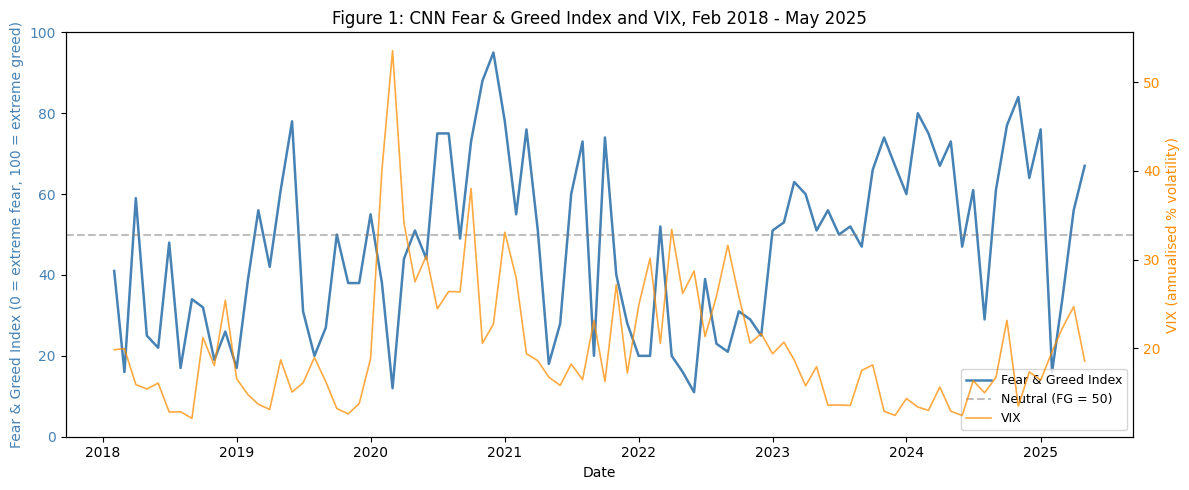

In [ ]:
# Figure 1: CNN Fear & Greed Index and VIX over the sample period
# Plots the end-of-month F&G level (left axis) alongside VIX (right axis).
# Annotated episodes: COVID-19 crash (Mar 2020), 2022 monetary tightening
# cycle, and the August 2024 volatility spike.
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fng_plot = fng_monthly[['Date', 'FearGreed']].set_index('Date').sort_index()
vix_plot = vix_df[['Date', 'VIX']].set_index('Date').sort_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(fng_plot.index, fng_plot['FearGreed'],
         color='steelblue', linewidth=1.8, label='Fear & Greed Index')
ax1.axhline(50, color='gray', linestyle='--', alpha=0.5,
            label='Neutral (FG = 50)')
ax1.set_ylabel('Fear & Greed Index (0 = extreme fear, 100 = extreme greed)',
               color='steelblue')
ax1.set_xlabel('Date')
ax1.set_ylim(0, 100)
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(vix_plot.index, vix_plot['VIX'],
         color='darkorange', linewidth=1.2, alpha=0.75, label='VIX')
ax2.set_ylabel('VIX (annualised % volatility)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

# Annotate notable episodes by anchoring text to the F&G axis
episodes = [
    ('2020-03-31', 'COVID-19 crash'),
    ('2022-09-30', '2022 tightening trough'),
    ('2024-08-31', 'Aug-2024 spike'),
]
for date_str, label in episodes:
    d = pd.Timestamp(date_str)
    if d in fng_plot.index:
        y = fng_plot.loc[d, 'FearGreed']
        ax1.annotate(
            label,
            xy=(d, y),
            xytext=(d, min(y + 25, 95)),
            arrowprops=dict(arrowstyle='->', alpha=0.6, color='black'),
            fontsize=9, ha='center',
        )

ax1.set_title('Figure 1: CNN Fear & Greed Index and VIX, '
              'Feb 2018 - May 2025')
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=9)

fig.tight_layout()
plt.show()


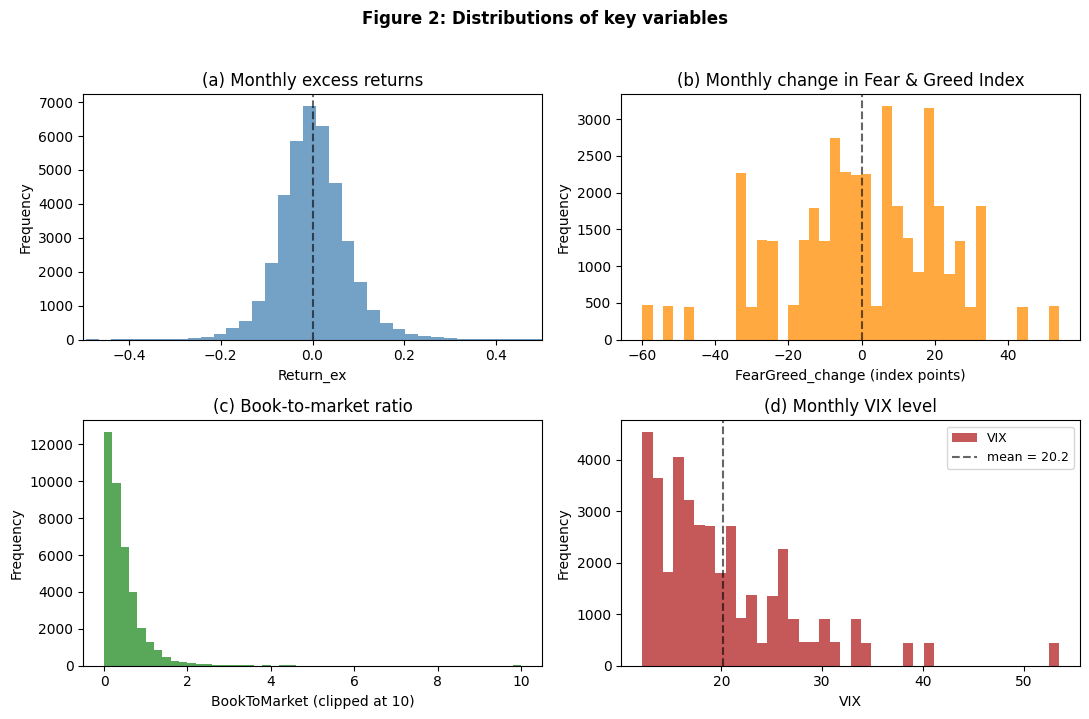

In [ ]:
# Figure 2: Distributions of key variables
# Histograms of monthly excess returns, monthly first difference in F&G,
# the book-to-market ratio, and the monthly VIX level. The dashed line
# marks zero (or the sample mean for VIX).
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# (a) Monthly excess returns
panel['Return_ex'].dropna().plot.hist(
    bins=80, ax=axes[0, 0], color='steelblue', alpha=0.75)
axes[0, 0].axvline(0, color='black', linestyle='--', alpha=0.6)
axes[0, 0].set_title('(a) Monthly excess returns')
axes[0, 0].set_xlabel('Return_ex')
axes[0, 0].set_xlim(-0.5, 0.5)  # truncate display; tails are real

# (b) Monthly F&G change
panel['FearGreed_change'].dropna().plot.hist(
    bins=40, ax=axes[0, 1], color='darkorange', alpha=0.75)
axes[0, 1].axvline(0, color='black', linestyle='--', alpha=0.6)
axes[0, 1].set_title('(b) Monthly change in Fear & Greed Index')
axes[0, 1].set_xlabel('FearGreed_change (index points)')

# (c) Book-to-Market
panel['BookToMarket'].dropna().plot.hist(
    bins=50, ax=axes[1, 0], color='forestgreen', alpha=0.75)
axes[1, 0].set_title('(c) Book-to-market ratio')
axes[1, 0].set_xlabel('BookToMarket (clipped at 10)')

# (d) VIX
panel['VIX'].dropna().plot.hist(
    bins=40, ax=axes[1, 1], color='firebrick', alpha=0.75)
axes[1, 1].axvline(panel['VIX'].mean(), color='black',
                   linestyle='--', alpha=0.6,
                   label=f"mean = {panel['VIX'].mean():.1f}")
axes[1, 1].set_title('(d) Monthly VIX level')
axes[1, 1].set_xlabel('VIX')
axes[1, 1].legend(fontsize=9)

fig.suptitle('Figure 2: Distributions of key variables', y=1.02,
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()


In [ ]:
print("Running regressions with Year FE and double-clustered SEs...")

import statsmodels.formula.api as smf
import scipy.stats as stats

panel = panel.sort_values(['Ticker', 'Date'])

panel['Return_ex_fwd1']  = panel.groupby('Ticker')['Return_ex'].shift(-1)
panel['Return_ex_fwd3']  = panel.groupby('Ticker')['Return_ex'].shift(-3)
panel['Return_ex_fwd12'] = panel.groupby('Ticker')['Return_ex'].shift(-12)

panel['FG_x_lnRevenue']    = panel['FearGreed_change'] * panel['lnRevenue']
panel['FG_x_BookToMarket'] = panel['FearGreed_change'] * panel['BookToMarket']

for horizon, y_var in [
    ('1 month', 'Return_ex_fwd1'),
    ('3 months', 'Return_ex_fwd3'),
    ('12 months', 'Return_ex_fwd12')
]:
    reg_data = panel.dropna(subset=[
        y_var, 'FearGreed_change', 'FG_dist_high', 'FG_dist_low',
        'VIX', 'VIX_change', 'lnRevenue', 'Leverage',
        'BookToMarket', 'Ret_1m', 'Ret_6m',
        'FG_x_lnRevenue', 'FG_x_BookToMarket',
        'Ticker_int', 'YearMonth_int'
    ]).copy()

    formula = f"""
    {y_var} ~ FearGreed_change + FG_dist_high + FG_dist_low +
    VIX + VIX_change +
    lnRevenue + Leverage + BookToMarket +
    Ret_1m + Ret_6m +
    FG_x_lnRevenue + FG_x_BookToMarket +
    C(Year)
    """

    model_base  = smf.ols(formula, data=reg_data).fit()
    model_firm  = smf.ols(formula, data=reg_data).fit(
        cov_type='cluster',
        cov_kwds={'groups': reg_data['Ticker_int'].values}
    )
    model_month = smf.ols(formula, data=reg_data).fit(
        cov_type='cluster',
        cov_kwds={'groups': reg_data['YearMonth_int'].values}
    )

    V_double  = model_firm.cov_params() + model_month.cov_params() - model_base.cov_params()
    se_double = np.sqrt(np.diag(V_double))
    t_stats   = model_base.params / se_double
    dof       = min(reg_data['Ticker_int'].nunique(), reg_data['YearMonth_int'].nunique()) - 1
    p_double  = 2 * stats.t.sf(np.abs(t_stats), df=dof)

    print(f"\n{'='*60}")
    print(f"HORIZON: {horizon}")
    print(f"Observations: {len(reg_data)}, Firms: {reg_data['Ticker_int'].nunique()}")
    print(f"R-squared: {model_base.rsquared:.4f}")
    print(f"\n{'Variable':<25} {'Coef':>12} {'P-value':>10}")
    print("-"*50)
    for var in ['FearGreed_change', 'FG_dist_high', 'FG_dist_low',
                'VIX', 'VIX_change', 'lnRevenue', 'Leverage', 'BookToMarket',
                'Ret_1m', 'Ret_6m', 'FG_x_lnRevenue', 'FG_x_BookToMarket', 'Intercept']:
        if var in model_base.params.index:
            coef = model_base.params[var]
            idx  = list(model_base.params.index).index(var)
            pval = p_double[idx]
            stars = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
            print(f"{var:<25} {coef:>12.6f} {pval:>10.4f} {stars}")

print("\nDone!")

Running regressions with Year FE and double-clustered SEs...

HORIZON: 1 month
Observations: 35357, Firms: 473
R-squared: 0.0088

Variable                          Coef    P-value
--------------------------------------------------
FearGreed_change              0.000834     0.3119 
FG_dist_high                  0.022340     0.0206 **
FG_dist_low                  -0.001048     0.3611 
VIX                           0.000262     0.5615 
VIX_change                    0.000815     0.9365 
lnRevenue                    -0.001221     0.1148 
Leverage                     -0.003233     0.5116 
BookToMarket                  0.003919     0.0505 *
Ret_1m                       -0.002634     0.8930 
Ret_6m                        0.009783     0.2367 
FG_x_lnRevenue               -0.000042     0.2418 
FG_x_BookToMarket            -0.000055     0.6452 
Intercept                     0.042913     0.0428 **

HORIZON: 3 months
Observations: 34412, Firms: 473
R-squared: 0.0140

Variable                       

In [ ]:
print("Fear & Greed change summary:")
print(fng_monthly[['FearGreed', 'FearGreed_change']].describe())
print("\nFirst 10 rows:")
print(fng_monthly[['Date', 'FearGreed', 'FearGreed_change']].head(10))

Fear & Greed change summary:
       FearGreed  FearGreed_change
count  88.000000         87.000000
mean   47.272727          0.298851
std    21.380906         21.649488
min    11.000000        -60.000000
25%    28.000000        -12.000000
50%    49.500000          0.000000
75%    63.250000         17.000000
max    95.000000         54.000000

First 10 rows:
        Date  FearGreed  FearGreed_change
0 2018-02-01         41               NaN
1 2018-03-01         16             -25.0
2 2018-04-01         59              43.0
3 2018-05-01         25             -34.0
4 2018-06-01         22              -3.0
5 2018-07-01         48              26.0
6 2018-08-01         17             -31.0
7 2018-09-01         34              17.0
8 2018-10-01         32              -2.0
9 2018-11-01         19             -13.0
